In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
from scipy.optimize import minimize

In [15]:
save = { #Se quiser salvar os resultados, basta colocar True, caso contrario, queria apenas os gráficos, deixe False
    'Nelder_mead': False, 
    'OF2': False,
    'COF': False,
}

In [16]:
def reset_save(): #Para garantir que uma vez que o codigo seja inicializado com a função de save, nenhum dado seja perdido 
    def reseter(path):
        arquivos = glob.glob(os.path.join(path, '*'))
            
        if not arquivos:
            print("A pasta já está vazia.")
        else:
            for arquivo in arquivos:
                try:
                    # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                    if os.path.isfile(arquivo):
                        os.remove(arquivo)
                        print(f"Arquivo apagado: {arquivo}")
                except Exception as e:
                    print(f"Erro ao tentar apagar {arquivo}: {e}")
                    
            print(f"Limpeza da pasta {path} concluída com sucesso!")

    if save['Nelder_mead']:
        reseter('.\\phase_tests\\results_nelder_mead')      

    if save['OF2']:
        reseter('.\\phase_tests\\results_of2')
        
    if save['COF']:
        reseter('.\\phase_tests\\results_cof')
        

In [17]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

bins   = [0, 50, 100, 150, 200, 300, np.inf]
labels = ['0–50', '50–100', '100–150', '150–200', '200–300', '300+']
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
columns = data[0].columns

cut = 4.5

for i in range(4):
    data[i]['phases'] = phase[i].values
    data[i]['AmplitudeRange'] = pd.cut(data[i]['AmplitudeSample(4)'], bins=bins, labels=labels, right=False)

columns = data[0].columns

In [18]:
#nelder-mead
def subtrai_estimada(sinalrecebido, resultado_neldermead):
    A = resultado_neldermead
    sample = sinalrecebido

    #Subtrai cada amplitude estimada do sinal recebido, considerando o padrão do sinal e ignorando a quarta amostra
    signalPattern = np.array([
            [A[0]*1.0    , A[1]*0.4524   , A[2]*0.0172   , 0             , 0             , 0             , 0],
            [A[0]*0.5633 , A[1]*1        , A[2]*0.4524   , A[3]*0.0172   , 0             , 0             , 0],
            [A[0]*0.1493 , A[1]*0.5633   , A[2]*1        , A[3]*0.4524   , A[4]*0.0172   , 0             , 0],
            [0           , 0             , 0             , 0             , 0             , 0             , 0],
            [0           , A[1]*0.0424   , A[2]*0.1493   , A[3]*0.5633   , A[4]*1        , A[5]*0.4524   , A[6]*0.0172],
            [0           , 0             , A[2]*0.0424   , A[3]*0.1493   , A[4]*0.5633   , A[5]*1        , A[6]*0.4524],
            [0           , 0             , 0             , A[3]*0.0424   , A[4]*0.1493   , A[5]*0.5633   , A[6]*1]
            ])
    
    for i in range(len(sinalrecebido)):
        sample = sample - signalPattern[i]
        #print(sample)
    
    return sample

def nelder_mead(df, tol):
    def cost_function(A):
        signalPattern = np.array([
                A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
                A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
                A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
                A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
                0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
                0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
                0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
                ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5

    def parada(xk):
            erro_atual = cost_function(xk)
            if erro_atual < tol:
                raise StopIteration  

    sample4 = [] #Valor da amplitude do quarto sample para a solução encontrada
    #fun_list = [] #Valor da função objetivo para a solução encontrada
    phase_estimated = [] #Valor da phase estimada para a solução encontrada

    b= [ -0.3085, 1.9086, 19.0859, 0.7363, -14.5817, -5.0529, -1.7877 ]

    for samples in df:
    
        res = minimize(cost_function, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        subtraida = subtrai_estimada(samples, res.x)
        phase_estimada = 0
        for i in range(len(subtraida)):
            phase_estimada += subtraida[i]*b[i]
        phase_estimada = phase_estimada/res.x[3] 
        
        sample4.append(res.x[3])
        phase_estimated.append(phase_estimada)
        
        
    return sample4, phase_estimated

In [19]:
#OF2
from matplotlib.pylab import test


def optimalFilter2(df):

    def of2Weights(df):

        pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
        d_pulse = np.array([0.00004019, 0.00333578, 0.03108120, 0.00000000, -0.02434490, -0.00800683, -0.00243344])
        #Para OF2 OTimizado
        # train = np.array(train).T
        # covarianceMatrix = np.cov(train)
        identidade = np.eye(7)
        b = np.zeros((10,10))
        b[ 0:7, 0:7 ] = identidade
        b[ 0:7, 7 ] = -pulse
        b[ 0:7, 8 ] = -d_pulse
        b[ 0:7, 9 ] = -1
        b[ 7, 0:7 ] = pulse
        b[ 8, 0:7 ] = d_pulse
        b[ 9, 0:7 ] = 1

        c = np.zeros((10, 1))
        c[7] = 1
        
        aux = np.linalg.solve( b, c )
        weights = aux[0:7].flatten()

        return weights

    weights = of2Weights( df )

    b= [ -0.3085, 1.9086, 19.0859, 0.7363, -14.5817, -5.0529, -1.7877 ]
    sample4 = []
    phase_estimated = []
    for sample in df:
        auxSample = sample * weights
        auxSample4 = sum(auxSample)
        phase_estimada = 0
        for i in range(len(sample)):
            phase_estimada += sample[i]*b[i]
        phase_estimada = phase_estimada/auxSample4

        sample4.append(auxSample4)
        phase_estimated.append(phase_estimada)

    return sample4, phase_estimated

In [20]:
#COF
def constrainedOptimalFilter(test, tol):

    pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
    S = np.array([
        [pulse[3],   pulse[4],   pulse[5],   pulse[6],   0.0,       0.0,        0.0     ],
        [pulse[2],   pulse[3],   pulse[4],   pulse[5],   pulse[6],  0.0,        0.0     ],
        [pulse[1],   pulse[2],   pulse[3],   pulse[4],   pulse[5],  pulse[6],   0.0     ],
        [pulse[0],   pulse[1],   pulse[2],   pulse[3],   pulse[4],  pulse[5],   pulse[6]],
        [0.0,        pulse[0],   pulse[1],   pulse[2],   pulse[3],  pulse[4],   pulse[5]],
        [0.0,        0.0,        pulse[0],   pulse[1],   pulse[2],  pulse[3],   pulse[4]],
        [0.0,        0.0,        0.0,        pulse[0],   pulse[1],  pulse[2],   pulse[3]]
    ])

    inv_S = np.linalg.inv(S)
    
    sample4 = []
    phase_estimated = []
    b= [ -0.3085, 1.9086, 19.0859, 0.7363, -14.5817, -5.0529, -1.7877 ]
    for samples in test:
        initial_estimative = inv_S @ samples

        cent = 3
        active_pulses = np.zeros(7)
        active_pulses[cent] = 1

        for j in range(7):
            if j == cent:
                continue

            if initial_estimative[j] > tol:
                active_pulses[j] = 1

        D_rows = []
        count = 0
        ind = 0
        
        for j in range(7):
            if active_pulses[j] == 1:
                # Descobre qual linha da nova matriz D corresponde ao pulso central
                if j == cent:
                    ind = count
                
                # Adiciona a linha j da matriz S
                D_rows.append(S[j, :])
                count += 1
                
        D = np.array(D_rows)
        
        # Recálculo dos pesos ótimos
        w = np.linalg.inv(D @ D.T) @ D
        
        # Aplicação do filtro restrito na janela de amostras atual
        out = samples @ w.T
        phase_estimada = 0
        for i in range(len(samples)):
            phase_estimada += samples[i]*b[i]
        phase_estimada = phase_estimada/out[ind]
        
        # Guarda o valor referente ao pulso central (sample4)
        sample4.append(out[ind])
        phase_estimated.append(phase_estimada)

    return sample4, phase_estimated

In [21]:
def save_method(sample4, occ, phase, ns_list, amplitude, amplitude_range, method):
    path = f'.\\phase_tests\\results_{method}\\{method}_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'PhaseError': np.array(ns_list) - np.array(phase),
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'AmplitudeRange': amplitude_range})
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'PhaseError': np.array(ns_list) - np.array(phase),
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'AmplitudeRange': amplitude_range
        })

    df.to_csv(f'.\\phase_tests\\results_{method}\\{method}_{occ}.csv', index=False)

In [22]:
def run_algorithm(data):

    reset_save()
    
    for i in range(len(data)):
        samples_data = np.array(data[i][columns[0:7]])
        amplitudes_data = np.array(data[i][columns[7]])
        phases_data = np.array(data[i]['phases'])
        range_data = np.array(data[i]['AmplitudeRange'])

        if save['Nelder_mead']:
            sample4, ns_list = nelder_mead(samples_data, tol=1)
            save_method(sample4, occ_name[i], phases_data, ns_list, amplitudes_data, range_data, method='nm')

        if save['OF2']:
            sample4, ns_list = optimalFilter2(samples_data)
            save_method(sample4, occ_name[i], phases_data, ns_list, amplitudes_data, range_data, method='of2')

        if save['COF']:
            sample4, ns_list = constrainedOptimalFilter(samples_data, tol=0.5)
            save_method(sample4, occ_name[i], phases_data, ns_list, amplitudes_data, range_data, method='cof')

In [23]:
run_algorithm(data)

In [24]:
def load_results():
    nm = [
        pd.read_csv(r'.\phase_tests\results_nm\nm_occ0.2.csv'),
        pd.read_csv(r'.\phase_tests\results_nm\nm_occ0.5.csv'),
        pd.read_csv(r'.\phase_tests\results_nm\nm_occ0.7.csv'),
        pd.read_csv(r'.\phase_tests\results_nm\nm_occ0.9.csv'),]

    of = [
        pd.read_csv(r'.\phase_tests\results_of2\of2_occ0.2.csv'),
        pd.read_csv(r'.\phase_tests\results_of2\of2_occ0.5.csv'),
        pd.read_csv(r'.\phase_tests\results_of2\of2_occ0.7.csv'),
        pd.read_csv(r'.\phase_tests\results_of2\of2_occ0.9.csv'),]

    cof = [
        pd.read_csv(r'.\phase_tests\results_cof\cof_occ0.2.csv'),
        pd.read_csv(r'.\phase_tests\results_cof\cof_occ0.5.csv'),
        pd.read_csv(r'.\phase_tests\results_cof\cof_occ0.7.csv'),
        pd.read_csv(r'.\phase_tests\results_cof\cof_occ0.9.csv'),]

    return nm, of, cof

In [25]:
nm, of, cof = load_results()

for i in range(len(of)):
    print(f"Occupancy: {occ_name[i]}")
    print(f"Nelder-Mead Mean Phase Error: {np.mean(nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut])}, STD: {np.std(nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut])}")
    print(f"OF2 Mean Phase Error: {np.mean(of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut])}, STD: {np.std(of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut])}")
    print(f"COF Mean Phase Error: {np.mean(cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut])}, STD: {np.std(cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut])}")


Occupancy: occ0.2
Nelder-Mead Mean Phase Error: 5.434252287188142, STD: 67.28570734021055
OF2 Mean Phase Error: -0.26532334256025486, STD: 67.75192203464138
COF Mean Phase Error: 4.1571737394880275, STD: 97.33923619134832
Occupancy: occ0.5
Nelder-Mead Mean Phase Error: 4.217185500956495, STD: 80.90594399106281
OF2 Mean Phase Error: -0.3726706483812304, STD: 95.60802734085722
COF Mean Phase Error: 3.9401873204795943, STD: 115.16762190408649
Occupancy: occ0.7
Nelder-Mead Mean Phase Error: 3.161554898503176, STD: 74.20809343686297
OF2 Mean Phase Error: -0.4909045572049309, STD: 101.6337071611544
COF Mean Phase Error: 2.30000103455645, STD: 111.51717948657449
Occupancy: occ0.9
Nelder-Mead Mean Phase Error: 2.949726833344022, STD: 70.8172854992446
OF2 Mean Phase Error: -0.7978862288270807, STD: 107.59298137991361
COF Mean Phase Error: 2.2910474914971073, STD: 107.36414337478774


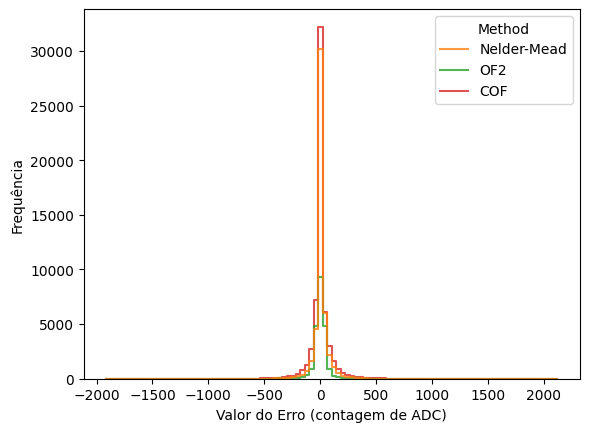

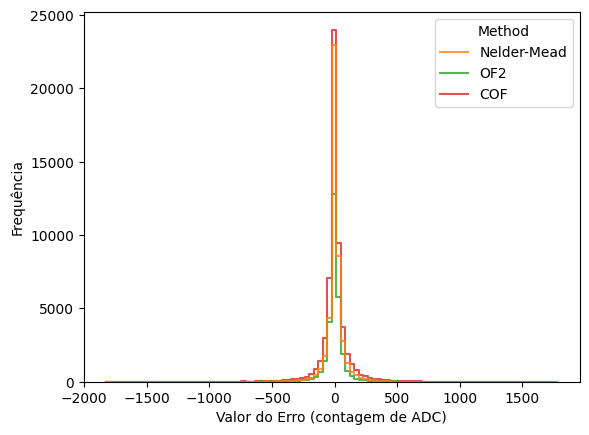

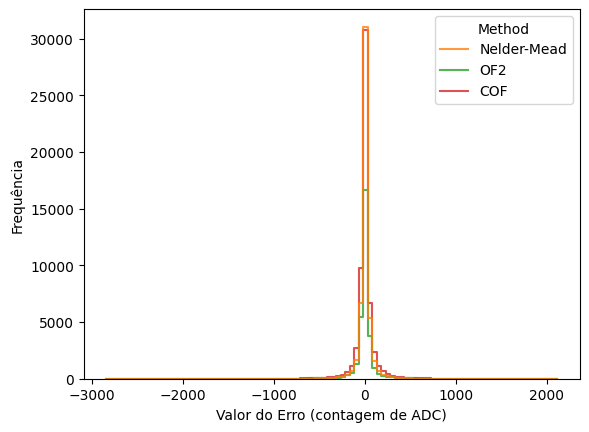

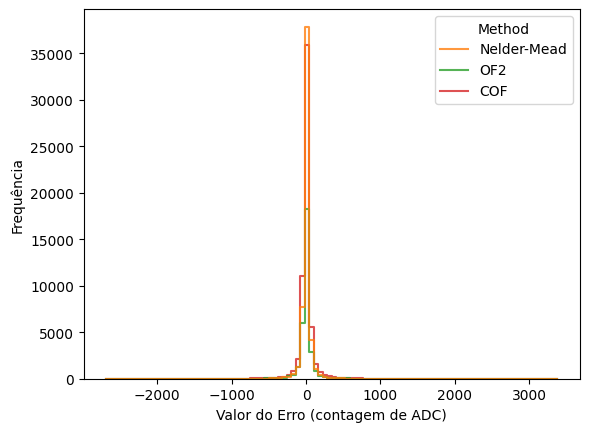

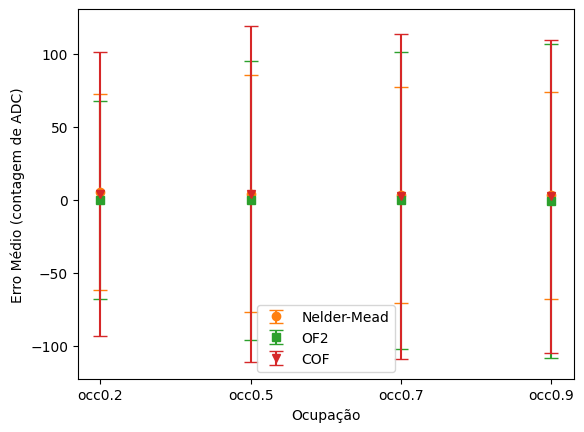

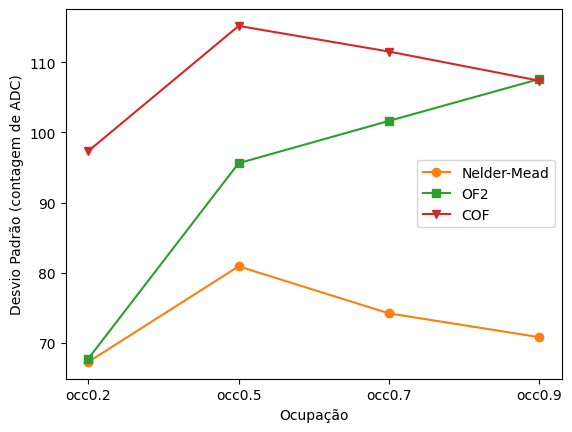

In [26]:
nm, of, cof = load_results()
fsize = 10

palette = [
    "#ff7f0e",  # Nelder-Mead
    "#2ca02c",  # OF2
    "#d62728",  # COF
]

for i in range(len(of)):
    
    results = pd.concat([
            pd.DataFrame({"Residual Value": nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut], "Method": f"Nelder-Mead"}),
            pd.DataFrame({"Residual Value": of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut], "Method": f"OF2"}),
            pd.DataFrame({"Residual Value": cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut], "Method": f"COF"}),
        ])
    plt.Figure(figsize=(10, 6))
    sns.histplot(data=results, hue="Method", legend=True, x="Residual Value", bins=100, fill=False, element="step", palette=palette, alpha=0.8)

    plt.ylabel("Frequência", fontsize=fsize)
    plt.xlabel("Valor do Erro (contagem de ADC)", fontsize=fsize)
    
    plt.show()

plt.errorbar(x=occ_name[:4], y=[nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut].mean() for i in range(4)], yerr=[nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], fmt='o', label='Nelder-Mead', capsize=5, color=palette[0])
plt.errorbar(x=occ_name[:4], y=[of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut].mean() for i in range(4)], yerr=[of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], fmt='s', label='OF2', capsize=5, color=palette[1])
plt.errorbar(x=occ_name[:4], y=[cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut].mean() for i in range(4)], yerr=[cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], fmt='v', label='COF', capsize=5, color=palette[2])
plt.xlabel("Ocupação", fontsize=fsize)
plt.ylabel("Erro Médio (contagem de ADC)", fontsize=fsize)
plt.legend(fontsize=fsize)
plt.show()

plt.plot(occ_name[:4], [nm[i]['PhaseError'][nm[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], label='Nelder-Mead', marker='o', color=palette[0])
plt.plot(occ_name[:4], [of[i]['PhaseError'][of[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], label='OF2', marker='s', color=palette[1])
plt.plot(occ_name[:4], [cof[i]['PhaseError'][cof[i]['EstimatedAmplitude'] > cut].std() for i in range(4)], label='COF', marker='v', color=palette[2])
plt.xlabel("Ocupação", fontsize=fsize)
plt.ylabel("Desvio Padrão (contagem de ADC)", fontsize=fsize)
plt.legend(fontsize=fsize)
plt.show()

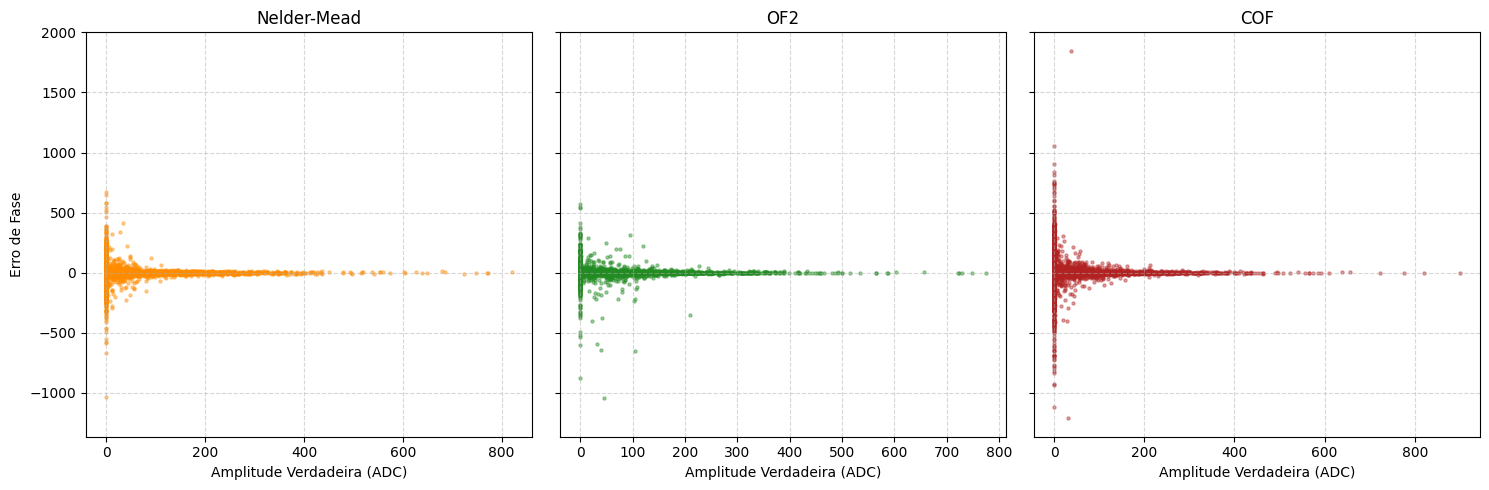

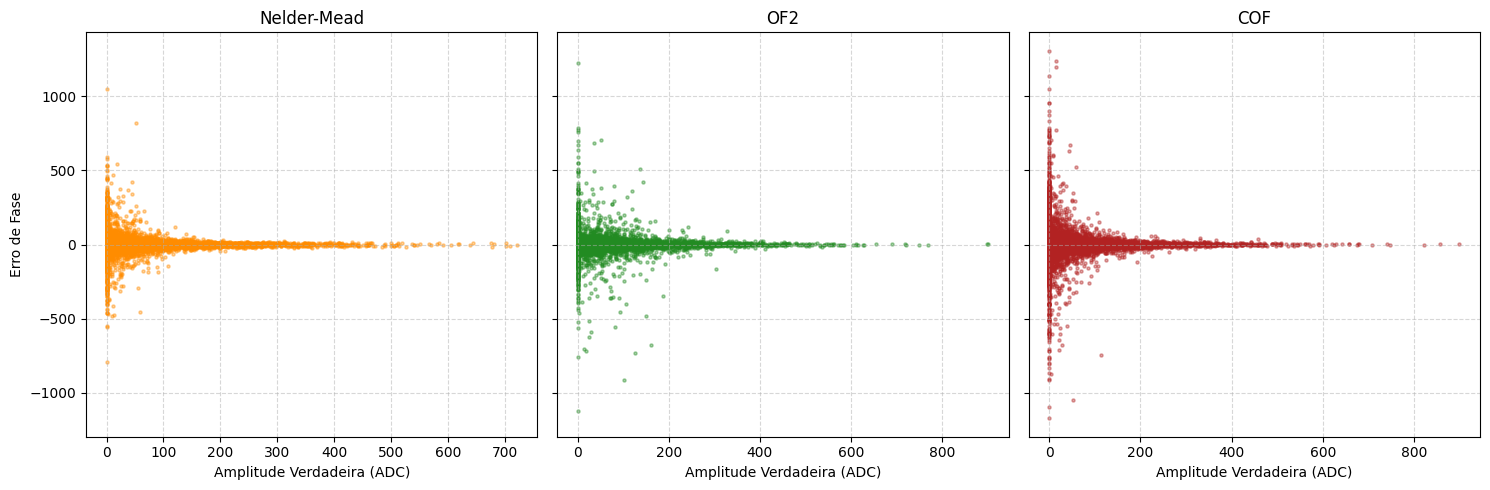

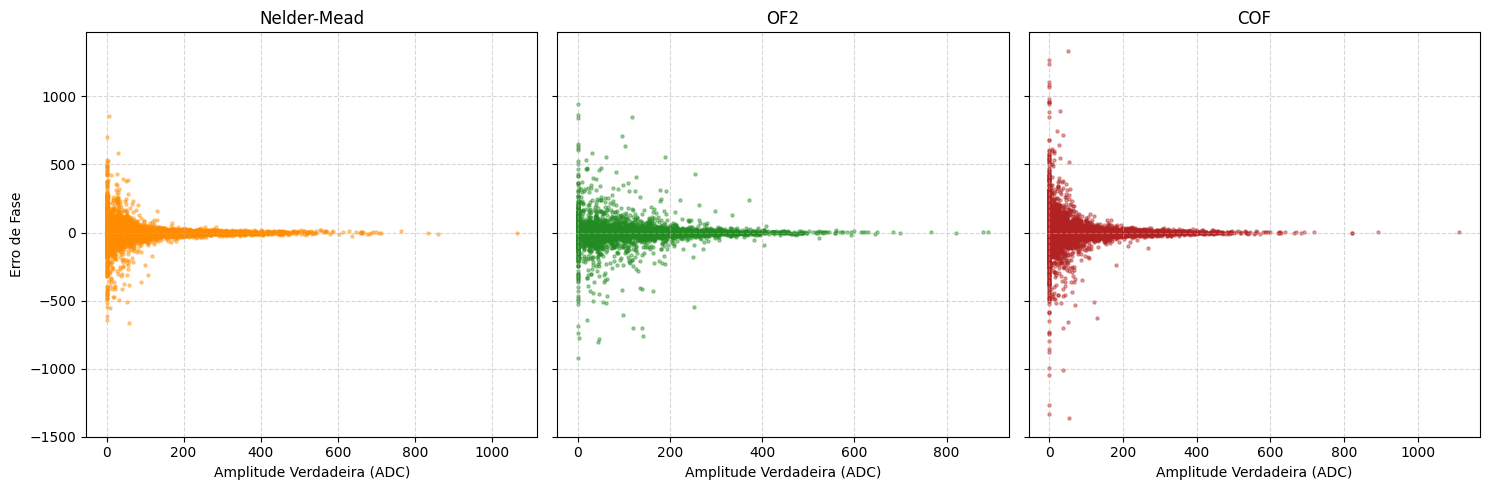

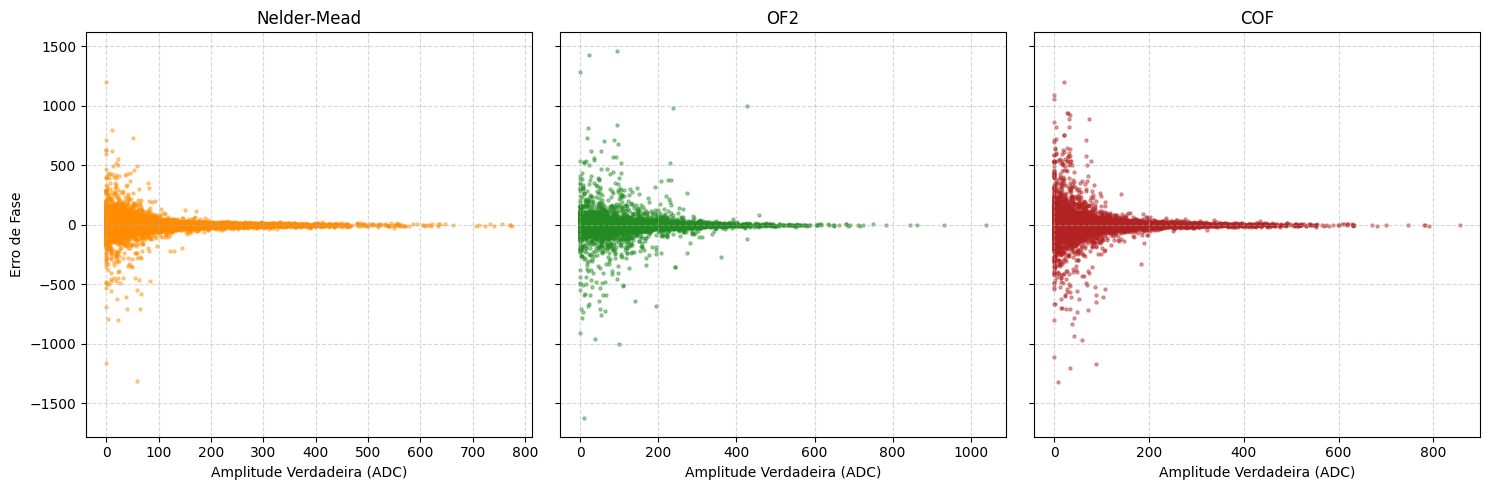

In [27]:
for i in range(len(of)):
    # sharey=True garante que os 3 gráficos usem a exata mesma escala no eixo Y
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    
    # Lista estruturada com Nome, DataFrame e Cor (ajuste as cores conforme sua 'palette')
    methods_data = [
        ("Nelder-Mead", nm[i], "darkorange"),
        ("OF2", of[i], "forestgreen"),
        ("COF", cof[i], "firebrick")
    ]
    
    for ax, (name, data, color) in zip(axes, methods_data):
        # 1. Aplica o filtro de amplitude
        mask = data['EstimatedAmplitude'] > cut
        x = data['TrueAmplitude'][mask]
        y = data['PhaseError'][mask]
        
        # 2. Amostragem para leveza extrema (plota 15% dos pontos). 
        # Remova o .sample se quiser plotar 100% dos dados filtrados.
        x_plot = x.sample(frac=0.15, random_state=42)
        y_plot = y.sample(frac=0.15, random_state=42)
        
        # 3. Desenha os pontos (s=5 define um tamanho de marcador pequeno, ideal para muitos dados)
        ax.scatter(x_plot, y_plot, color=color, alpha=0.4, s=5)
        
        # 4. Formatação de cada subplot
        ax.set_title(name, fontsize=12)
        ax.set_xlabel("Amplitude Verdadeira (ADC)", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
        
    # O eixo Y só precisa ser nomeado no primeiro gráfico da esquerda
    axes[0].set_ylabel("Erro de Fase", fontsize=10)
    
    # Ajusta o espaçamento para não cortar os textos
    plt.tight_layout()
    plt.show()